In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
from sklearn.metrics import confusion_matrix
from PIL import Image
import os



In [2]:
# Пути к данным

PATH = 'C:/Users/Пользователь/Desktop/програмироание/frukta'           #создаём пути( буквально как путь к файлу)
TRAIN_PATH = PATH + '/train'#
TEST_PATH = PATH + '/test'#


In [3]:

# Преобразования для изображений
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [4]:

# Загрузка обучающей выборки (с подпапками классов)
train_dataset = ImageFolder(root=TRAIN_PATH, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [6]:


# Классы (фрукты, овощи, ягоды)
class_names = train_dataset.classes
print(class_names)

['berrie', 'fruits', 'vegeta']


In [6]:


# Создание собственного Dataset для тестовой выборки (без подпапок классов)
class TestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.image_files = [f for f in os.listdir(root) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name  # Возвращаем изображение и имя файла

In [7]:


# Загрузка тестовой выборки
test_dataset = TestDataset(root=TEST_PATH, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [8]:


# Функция для отображения изображений
def display_images(images, labels, class_names, n=10):
    rows, cols = 1, n
    fig = plt.figure(figsize=(15, 3))
    for i in range(n):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        ax.set_title(class_names[labels[i]])
        ax.axis('off')
    plt.show()


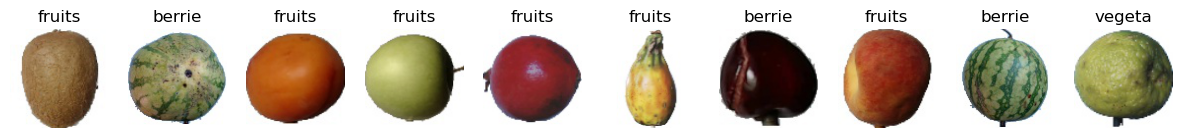

In [9]:


# Отображение первых 5 изображений из обучающей выборки
images, labels = next(iter(train_loader))
display_images(images, labels, class_names, n=10)

In [10]:


# Определение модели CNN
class Net(nn.Module):
    def __init__(self, num_classes=3):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 25 * 25, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 25 * 25)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [11]:


# Инициализация модели, функции потерь и оптимизатора
model = Net(num_classes=len(class_names))
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.01)

In [12]:


# Обучение модели
EPOCHS = 10
train_losses = []
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch + 1}, Loss: {epoch_loss}')

Epoch 1, Loss: 0.483878176144296
Epoch 2, Loss: 0.31570050637415215
Epoch 3, Loss: 0.1316706337683806
Epoch 4, Loss: 0.06154491030434711
Epoch 5, Loss: 0.0044267090287934425
Epoch 6, Loss: 0.001710830633035612
Epoch 7, Loss: 0.0003880139527263559
Epoch 8, Loss: 0.00011577469518983614
Epoch 9, Loss: 7.796688697444172e-05
Epoch 10, Loss: 3.9683652648822985e-05


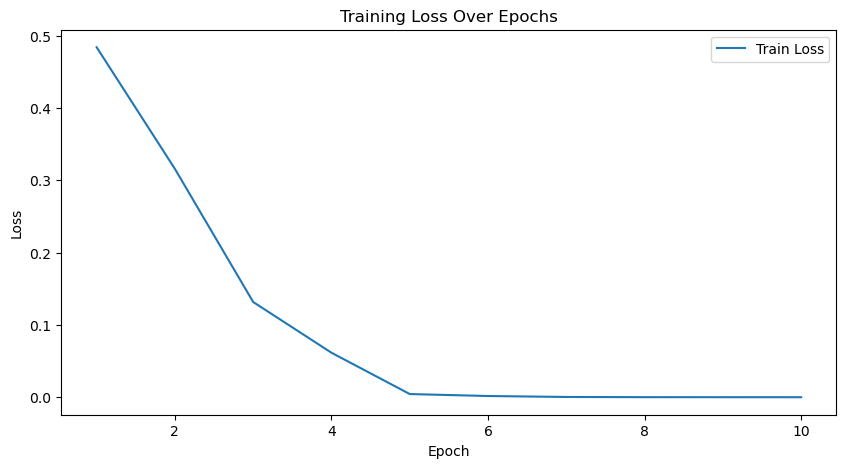

In [13]:


# График потерь
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, EPOCHS + 1), y=train_losses, label='Train Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [14]:


# Тестирование модели на обучающей выборке (для оценки точности)
model.eval()
correct = 0
total = 0
predicted_labels = []
true_labels = []
with torch.no_grad():
    for images, labels in train_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        predicted_labels.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy on Train Set: {100 * correct / total}%')

Test Accuracy on Train Set: 100.0%


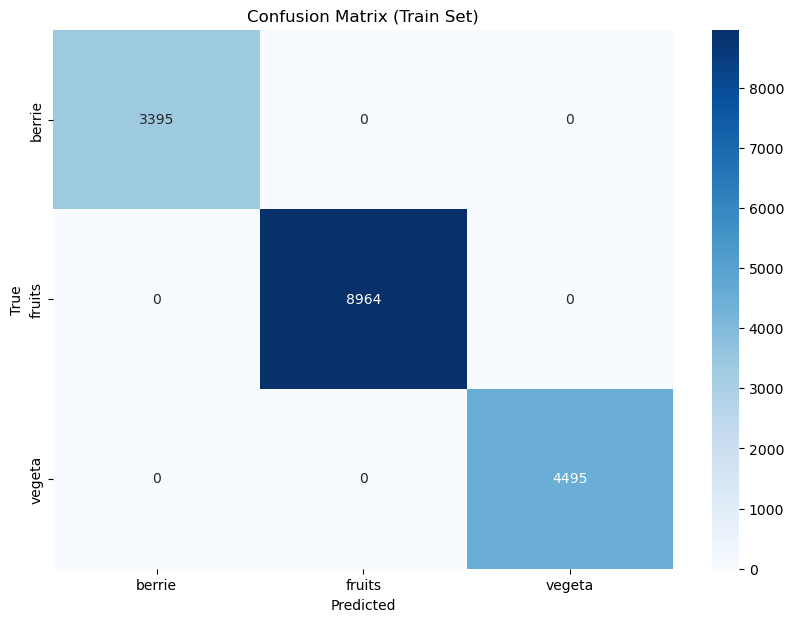

In [15]:


# Матрица ошибок для обучающей выборки
cm = confusion_matrix(true_labels, predicted_labels)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Train Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [16]:

# Визуализация тестовой выборки (без меток)
def display_test_images(images, filenames, n=5):
    rows, cols = 1, n
    fig = plt.figure(figsize=(15, 3))
    for i in range(n):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        ax.set_title(filenames[i])
        ax.axis('off')
    plt.show()

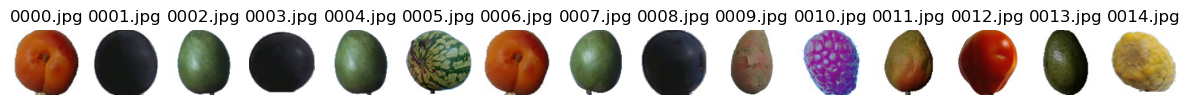

In [21]:


# Отображение первых 5 изображений из тестовой выборки
test_images, test_filenames = next(iter(test_loader))
display_test_images(test_images, test_filenames, n=15)

In [22]:

# Предсказание для тестовой выборки
model.eval()
test_predictions = []
with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())

In [25]:


# Сохранение предсказаний
test_results = pd.DataFrame({
    'Filename': test_dataset.image_files,
    'Predicted Class': [class_names[p] for p in test_predictions]
})
print(test_results.head(15))

    Filename Predicted Class
0   0000.jpg          fruits
1   0001.jpg          berrie
2   0002.jpg          fruits
3   0003.jpg          berrie
4   0004.jpg          fruits
5   0005.jpg          vegeta
6   0006.jpg          fruits
7   0007.jpg          fruits
8   0008.jpg          berrie
9   0009.jpg          vegeta
10  0010.jpg          berrie
11  0011.jpg          fruits
12  0012.jpg          vegeta
13  0013.jpg          vegeta
14  0014.jpg          vegeta


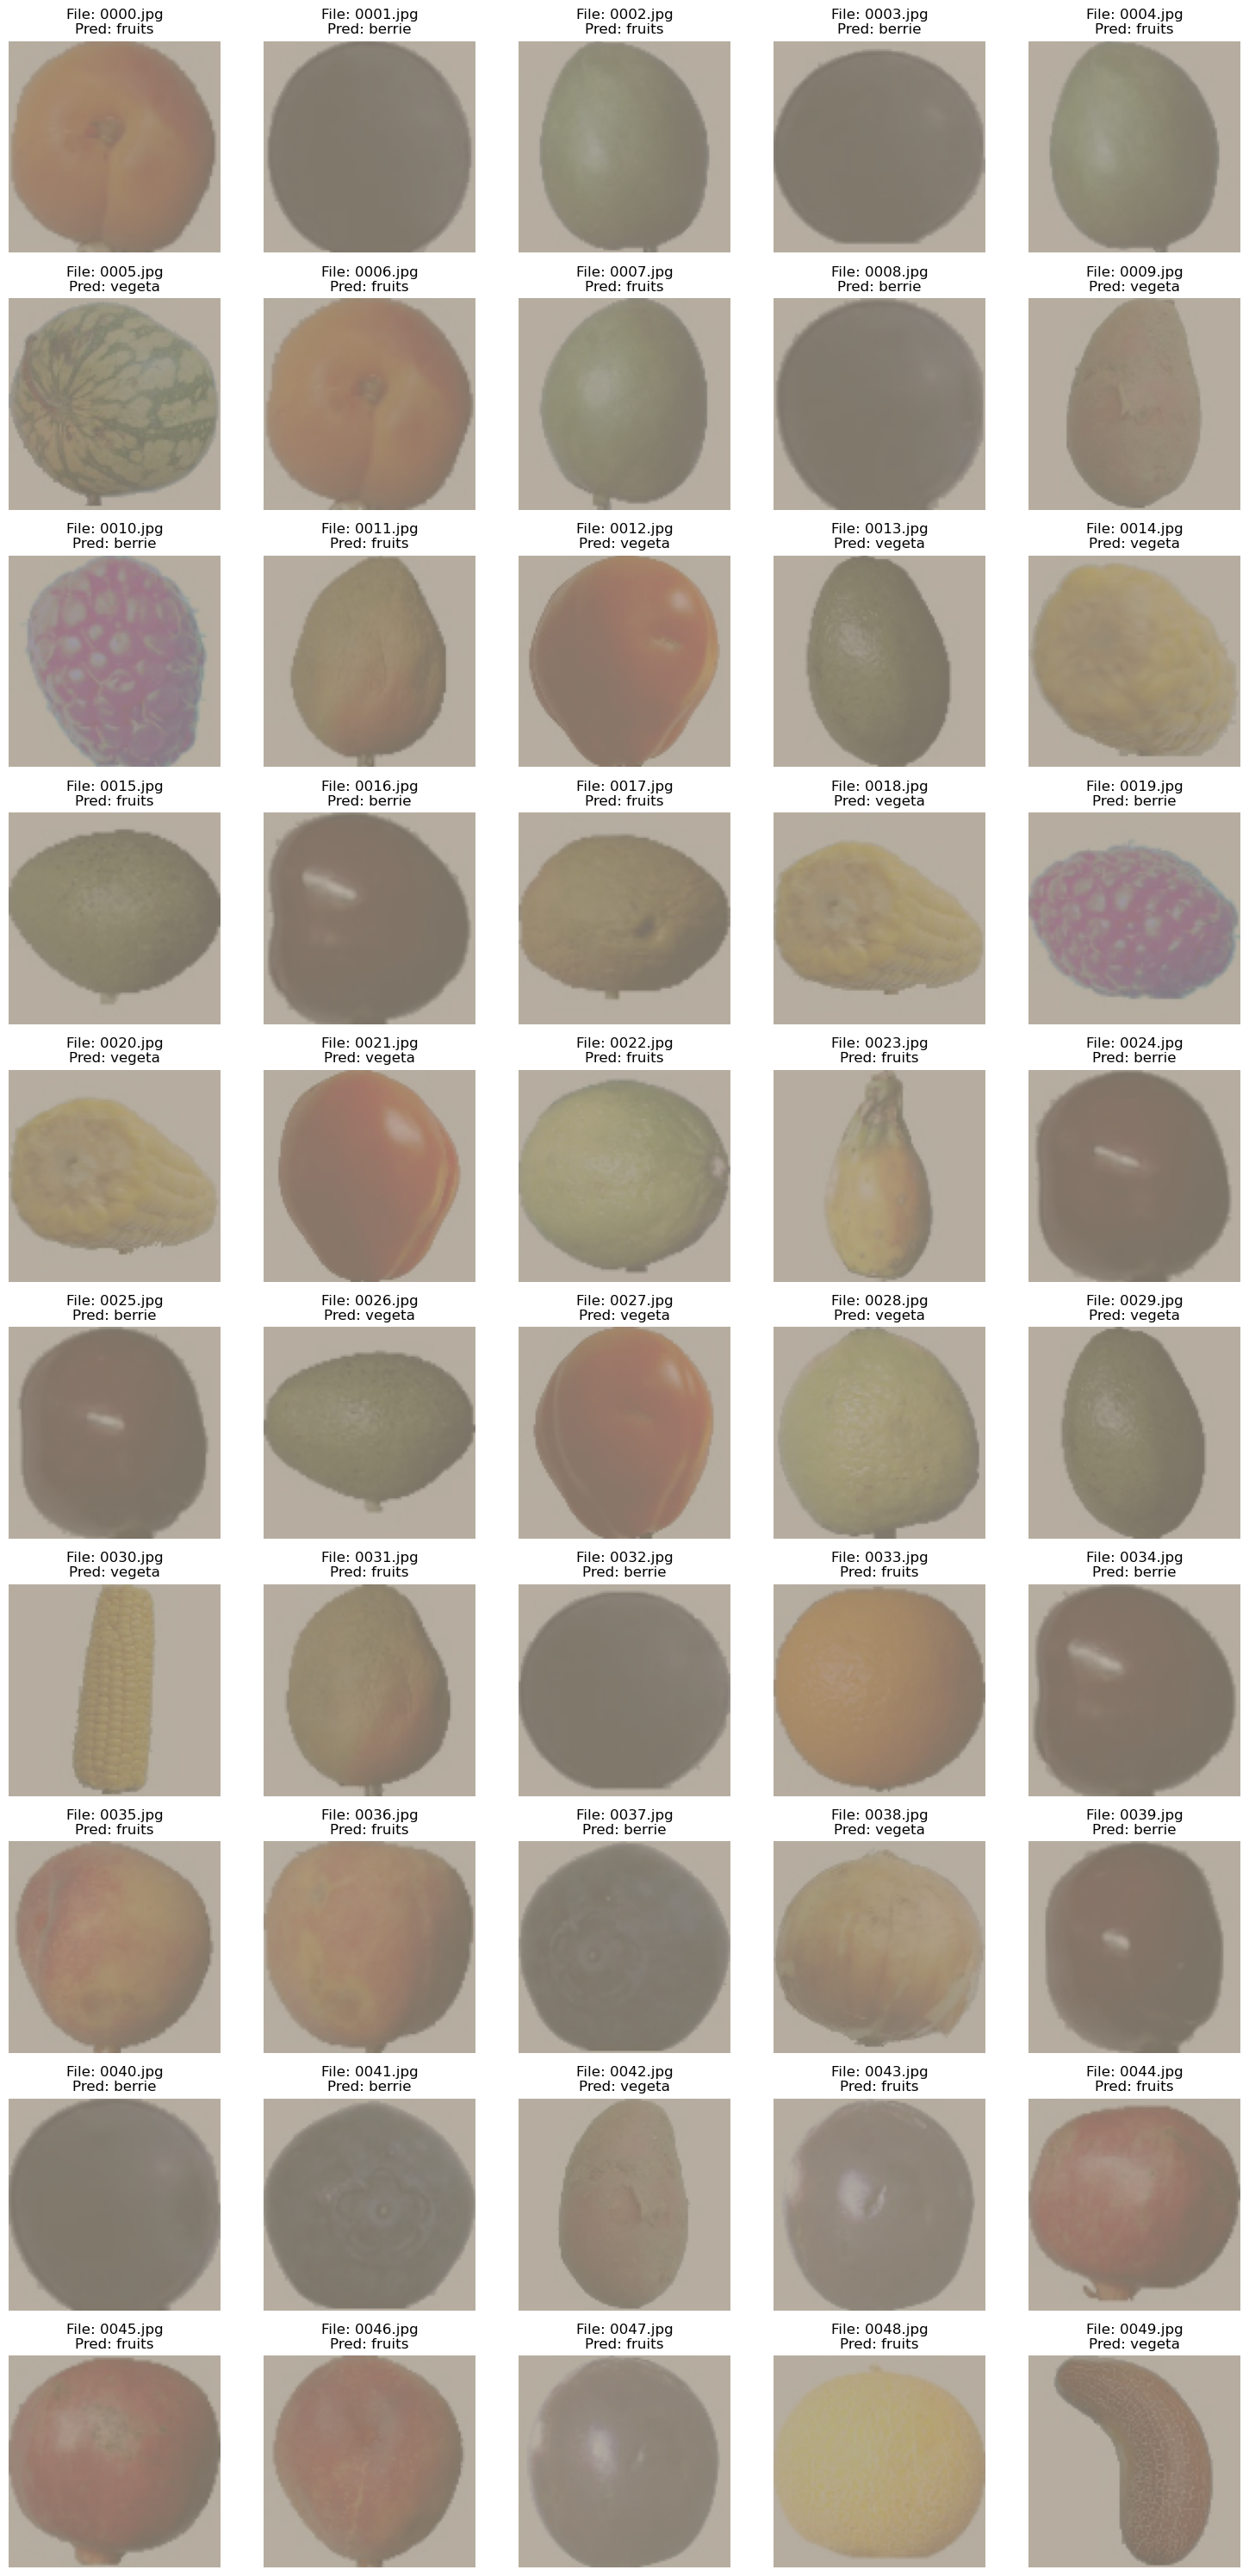

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Функция для отмены нормализации
def denormalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    Отменяет нормализацию изображения.
    
    :param image: Тензор изображения (C, H, W).
    :param mean: Средние значения, использованные для нормализации.
    :param std: Стандартные отклонения, использованные для нормализации.
    :return: Денормализованное изображение в формате (H, W, C).
    """
    image = image.clone().cpu().numpy()  # Копируем и преобразуем в numpy
    for i in range(3):  # Для каждого канала (R, G, B)
        image[i] = image[i] * std[i] + mean[i]  # Отменяем нормализацию
    image = np.clip(image, 0, 1)  # Обрезаем значения до [0, 1]
    image = np.transpose(image, (1, 2, 0))  # Меняем порядок осей на (H, W, C)
    return image

# Функция для отрисовки тестовых изображений с предсказанными классами
def display_test_images(images, filenames, predicted_classes, class_names, n=10, cols=5):
    """
    Отображает тестовые изображения с предсказанными классами.
    
    :param images: Список тензоров изображений (batch_size, channels, height, width).
    :param filenames: Список имён файлов.
    :param predicted_classes: Список предсказанных классов (индексы).
    :param class_names: Список названий классов.
    :param n: Количество изображений для отображения.
    :param cols: Количество изображений в строке.
    """
    rows = math.ceil(n / cols)  # Количество строк
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    
    # Если изображений меньше, чем cols * rows, скрываем лишние оси
    for i in range(n, rows * cols):
        row = i // cols
        col = i % cols
        axes[row, col].axis('off')

    # Отображаем изображения
    for i in range(n):
        row = i // cols  # Номер строки
        col = i % cols   # Номер столбца
        ax = axes[row, col]
        
        # Денормализуем изображение
        denorm_image = denormalize(images[i])
        # Масштабируем до [0, 255] и преобразуем в uint8
        denorm_image = (denorm_image * 255).astype(np.uint8)
        ax.imshow(denorm_image)
        ax.set_title(f"File: {filenames[i]}\nPred: {class_names[predicted_classes[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Предсказание для тестовой выборки
model.eval()
test_predictions = []
test_images_list = []
test_filenames_list = []

with torch.no_grad():
    for images, filenames in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_images_list.extend(images.cpu())  # Сохраняем изображения для отрисовки
        test_filenames_list.extend(filenames)  # Сохраняем имена файлов

# Отображение тестовых изображений с предсказанными классами
n_images = 50  # Количество изображений для отображения
display_test_images(test_images_list, test_filenames_list, test_predictions, class_names, n=n_images, cols=5)

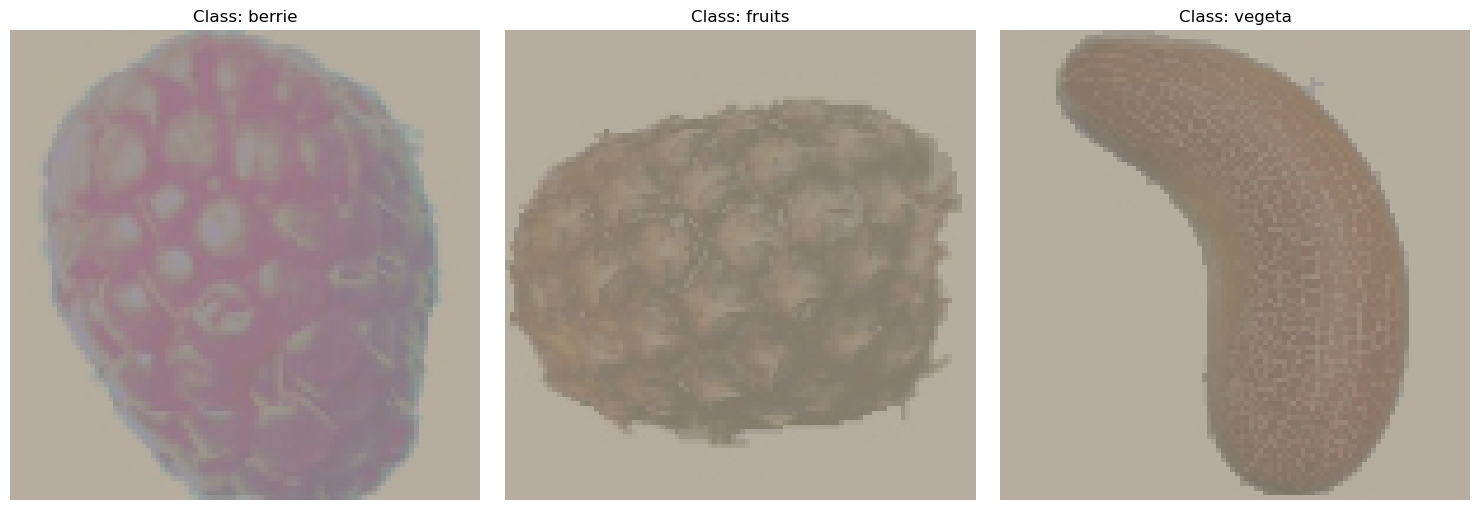

In [31]:

import matplotlib.pyplot as plt
import random

# Функция для отмены нормализации
def denormalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    Отменяет нормализацию изображения.
    
    :param image: Тензор изображения (C, H, W).
    :param mean: Средние значения, использованные для нормализации.
    :param std: Стандартные отклонения, использованные для нормализации.
    :return: Денормализованное изображение в формате (H, W, C).
    """
    image = image.clone().cpu().numpy()  # Копируем и преобразуем в numpy
    for i in range(3):  # Для каждого канала (R, G, B)
        image[i] = image[i] * std[i] + mean[i]  # Отменяем нормализацию
    image = np.clip(image, 0, 1)  # Обрезаем значения до [0, 1]
    image = np.transpose(image, (1, 2, 0))  # Меняем порядок осей на (H, W, C)
    return image

# Функция для отрисовки изображений по классам
def display_images_by_class(images_by_class, class_names):
    """
    Отображает случайные изображения для каждого класса.
    
    :param images_by_class: Словарь, где ключи — классы, а значения — списки изображений.
    :param class_names: Список названий классов.
    """
    fig, axes = plt.subplots(1, len(class_names), figsize=(15, 5))
    for i, class_name in enumerate(class_names):
        if class_name in images_by_class and len(images_by_class[class_name]) > 0:
            # Выбираем случайное изображение для класса
            random_image = random.choice(images_by_class[class_name])
            # Денормализуем изображение
            denorm_image = denormalize(random_image)
            # Масштабируем до [0, 255] и преобразуем в uint8
            denorm_image = (denorm_image * 255).astype(np.uint8)
            axes[i].imshow(denorm_image)
            axes[i].set_title(f"Class: {class_name}")
            axes[i].axis('off')
        else:
            axes[i].axis('off')  # Скрываем ось, если нет изображений для класса
    plt.tight_layout()
    plt.show()

# Предсказание для тестовой выборки
model.eval()
test_predictions = []
test_images_list = []
test_filenames_list = []

with torch.no_grad():
    for images, filenames in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_images_list.extend(images.cpu())  # Сохраняем изображения для отрисовки
        test_filenames_list.extend(filenames)  # Сохраняем имена файлов

# Группируем изображения по классам
images_by_class = {class_name: [] for class_name in class_names}
for image, prediction in zip(test_images_list, test_predictions):
    class_name = class_names[prediction]
    images_by_class[class_name].append(image)

# Отображаем случайные изображения для каждого класса
display_images_by_class(images_by_class, class_names)

Generating image for class: fruits
Iteration 10, Loss: 1.0236834287643433
Iteration 20, Loss: 1.0153926610946655
Iteration 30, Loss: 1.006799578666687
Iteration 40, Loss: 0.9981737732887268
Iteration 50, Loss: 0.9895385503768921
Iteration 60, Loss: 0.9809770584106445
Iteration 70, Loss: 0.972514271736145
Iteration 80, Loss: 0.9642410278320312
Iteration 90, Loss: 0.9560244083404541
Iteration 100, Loss: 0.9478728771209717
Iteration 110, Loss: 0.939790666103363
Iteration 120, Loss: 0.9317840933799744
Iteration 130, Loss: 0.9238648414611816
Iteration 140, Loss: 0.9160417914390564
Iteration 150, Loss: 0.9083700776100159
Iteration 160, Loss: 0.9008262753486633
Iteration 170, Loss: 0.8933799266815186
Iteration 180, Loss: 0.8860430717468262
Iteration 190, Loss: 0.878790557384491
Iteration 200, Loss: 0.8716182708740234
Iteration 210, Loss: 0.8644951581954956
Iteration 220, Loss: 0.8574295043945312
Iteration 230, Loss: 0.850426435470581
Iteration 240, Loss: 0.843496561050415
Iteration 250, Loss:

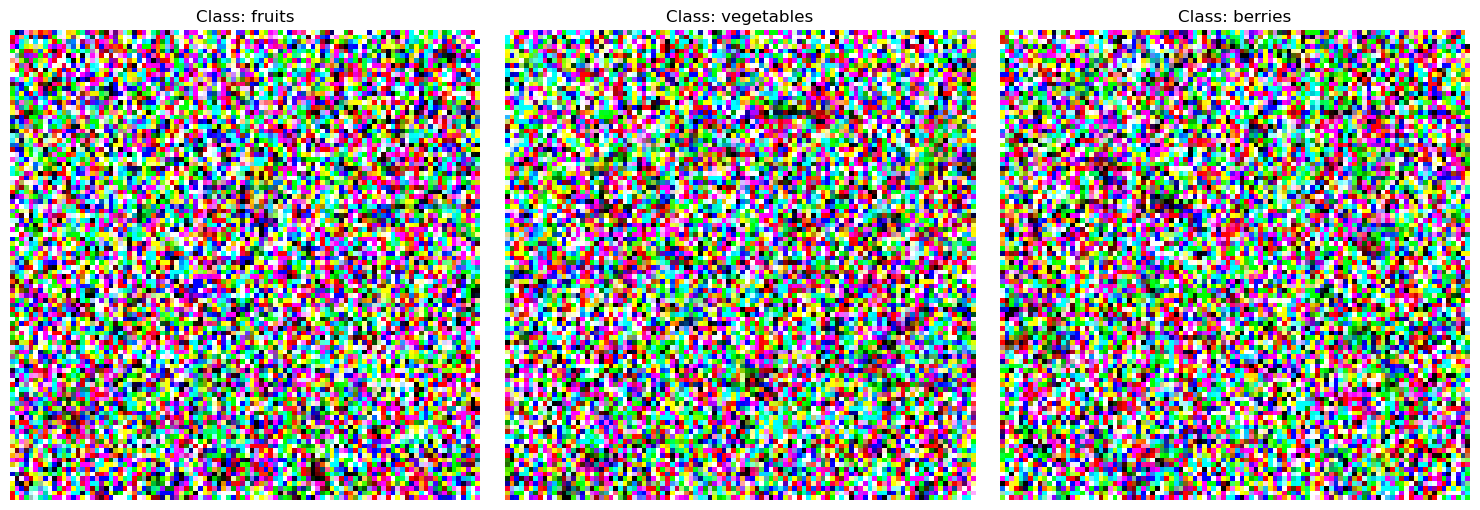

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Загрузка модели (предположим, что модель уже обучена)
model = Net(num_classes=3)  # Ваша модель
model.eval()  # Переводим модель в режим оценки

# Функция для генерации изображения
def generate_image_for_class(model, target_class, image_size=(100, 100), num_iterations=10000, lr=0.001):
    """
    Генерирует изображение, которое максимизирует активацию определённого класса.
    
    :param model: Обученная модель.
    :param target_class: Индекс целевого класса.
    :param image_size: Размер изображения (H, W).
    :param num_iterations: Количество итераций оптимизации.
    :param lr: Скорость обучения.
    :return: Сгенерированное изображение.
    """
    # Создаём изображение с белым фоном (значения 1.0)
    image = torch.ones(1, 3, *image_size, requires_grad=True)  # (batch_size, channels, height, width)
    
    # Оптимизатор для обновления изображения
    optimizer = optim.Adam([image], lr=lr)
    
    for i in range(num_iterations):
        optimizer.zero_grad()
        
        # Прогоняем изображение через модель
        output = model(image)
        
        # Вычисляем потерю (минимизируем отрицательную активацию целевого класса)
        loss = -output[0, target_class]  # Минус, потому что мы хотим максимизировать активацию
        
        # Обратное распространение
        loss.backward()
        
        # Обновляем изображение
        optimizer.step()
        
        # Ограничиваем значения пикселей в диапазоне [0, 1]
        with torch.no_grad():
            image.clamp_(0, 1)
        
        if (i + 1) % 10 == 0:
            print(f"Iteration {i + 1}, Loss: {loss.item()}")
    
    return image.detach()

# Генерация изображений для каждого класса
class_names = ['fruits', 'vegetables', 'berries']
generated_images = []

for class_idx, class_name in enumerate(class_names):
    print(f"Generating image for class: {class_name}")
    generated_image = generate_image_for_class(model, class_idx)
    generated_images.append(generated_image)

# Отрисовка сгенерированных изображений
def display_generated_images(generated_images, class_names):
    """
    Отображает сгенерированные изображения для каждого класса.
    
    :param generated_images: Список сгенерированных изображений.
    :param class_names: Список названий классов.
    """
    fig, axes = plt.subplots(1, len(class_names), figsize=(15, 5))
    for i, (image, class_name) in enumerate(zip(generated_images, class_names)):
        # Преобразуем тензор в numpy и меняем порядок осей
        image = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(image, cmap='gray' if image.shape[-1] == 1 else None)
        axes[i].set_title(f"Class: {class_name}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Отображаем сгенерированные изображения
display_generated_images(generated_images, class_names)